In [447]:
import os
# if use GPU, set the visible device to 0, if use CPU, set it to empty string, and make sure to set the device to 'cpu' in the training loop
# must set the visible device before importing torch, otherwise it will not work
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# for cpu setting
# os.environ["CUDA_VISIBLE_DEVICES"] = ""
# if use colab T4 GPU, remove all
import torch
import einops.layers.torch as elt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
%matplotlib inline

In [448]:
# check if GPU is available
print(torch.cuda.is_available())

# check any GPU device is available
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
Tesla T4


In [449]:
# if file is npy can use numpy directly read others with fromfile or pandas
x_train = np.load("/content/x_train.npy")
y_train_label = np.load("/content/y_train_label.npy")
# x_train[0] ↔ y_train_label[0]  ← same index, same image and label

In [450]:
x_train.shape, y_train_label.shape,  type(x_train)

((60000, 28, 28), (60000,), numpy.ndarray)

In [451]:
# it is two big , slow ,choose 10%

x_train_80,  y_train,y_train_label_80, y_test = train_test_split(x_train, y_train_label, test_size=0.20, random_state=42)
x_train = x_train_80
y_train_label = y_train_label_80
print(x_train.shape, y_train_label.shape)


(48000, 28, 28) (48000,)


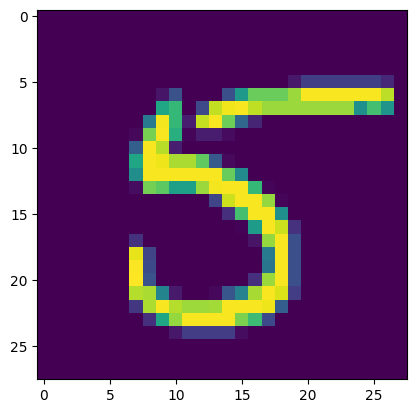

In [452]:
image = torch.tensor(x_train[0])
image = torch.squeeze(image, dim=0) #squeeze only remove value 1, with dim = n will remove dim[n]
image = image.numpy()
plt.imshow(image)
# plt.imshow(image, cmap="gray") no color

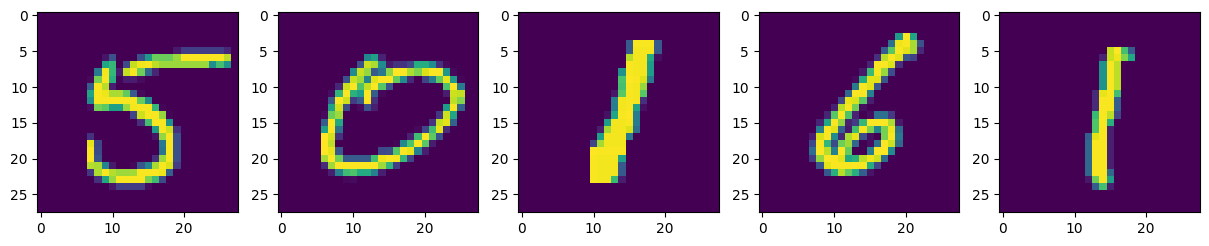

In [453]:
images = torch.tensor(x_train[:5])
fix,axes = plt.subplots(1,5, figsize=(15,15))
for i , ax in enumerate(axes):
  image = torch.squeeze(images[i], dim=1)
  image = images[i].numpy()
  ax.imshow(image)

In [454]:
class Unet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # in_channels accepts only 1 channel for color is only gray, not rgb
        # out_channels need 32 kernels(filters) output for (1, height, weight) to (32, height, weight)
        # kernel is 3 * 3
        # Padding refers to adding extra "fake" pixels (usually zeros) around the border of your input image before the kernel slides over it.

        # encoder
        self.encoder1 = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, 3, padding=1),
#normalizes the inputs of each layer to have a mean of 0 and standard deviation of 1 (during training).
            torch.nn.BatchNorm2d(32),
            torch.nn.GELU(),
            torch.nn.Conv2d(32, 32, 3, padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.GELU()
        )
        self.pool1 = torch.nn.MaxPool2d(2)

        self.encoder2 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, 3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.GELU(),
            torch.nn.Conv2d(64, 64, 3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.GELU(),
        )
        # seperate pooling layer, not in sequential, because we need to
        # save the output of encoder2 for skip connection
        self.pool2 = torch.nn.MaxPool2d(2)

        # bottleneck
        self.bottleneck = torch.nn.Sequential(
            torch.nn.Conv2d(64, 128, 3, padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.GELU(),
            torch.nn.Conv2d(128, 128, 3, padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.GELU()
        )

        # ========== decoder ==========
        # key：in decoder1 ，after interpolate need change channels by conv
        self.decoder1 = torch.nn.Sequential(
            # input: 128 channels (64 interpolate + 64 skip)
            torch.nn.Conv2d(128, 64, 3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.GELU(),
            torch.nn.Conv2d(64, 64, 3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.GELU()
        )

        self.decoder2 = torch.nn.Sequential(
            # input: 64 channels (32 interpolate + 32 skip)
            torch.nn.Conv2d(64, 32, 3, padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.GELU(),
            torch.nn.Conv2d(32, 32, 3, padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.GELU()
        )

        self.output = torch.nn.Conv2d(32, 1, 1)

    def forward(self, x):
        # encode
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))
        bottleneck = self.bottleneck(self.pool2(enc2))

        # ========== decoder  ==========
        # : interpolate upsampling
        dec1 = F.interpolate(bottleneck, size=enc2.shape[2:], mode='bilinear', align_corners=False)

        #  use 1x1 conv 128  → 64
        dec1 = self._upconv_channels(dec1, 64)  # 128 → 64

        # concatenate skip connection
        dec1 = torch.cat([dec1, enc2], dim=1)  # 64 + 64 = 128
        dec1 = self.decoder1(dec1)

        # second decoder
        dec2 = F.interpolate(dec1, size=enc1.shape[2:], mode='bilinear', align_corners=False)
        dec2 = self._upconv_channels(dec2, 32)  # 64 → 32
        dec2 = torch.cat([dec2, enc1], dim=1)  # 32 + 32 = 64
        dec2 = self.decoder2(dec2)

        # end output
        output = F.interpolate(dec2, size=x.shape[2:], mode='bilinear', align_corners=False)
        output = self.output(output)

        return output

    def _upconv_channels(self, x, out_channels):
        """用 1x1 卷积改变通道数"""
        if x.shape[1] != out_channels:
            x = torch.nn.Conv2d(x.shape[1], out_channels, 1)(x)
        return x


In [455]:
class UnetUpsamle(torch.nn.Module):
    def __init__(self):
        super().__init__()

        # encoder
        self.encoder1 = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, 3, padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.GELU(),
            torch.nn.Conv2d(32, 32, 3, padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.GELU()
        )
        self.pool1 = torch.nn.MaxPool2d(2)

        self.encoder2 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, 3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.GELU(),
            torch.nn.Conv2d(64, 64, 3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.GELU(),
        )
        self.pool2 = torch.nn.MaxPool2d(2)

        # bottleneck
        self.bottleneck = torch.nn.Sequential(
            torch.nn.Conv2d(64, 128, 3, padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.GELU(),
            torch.nn.Conv2d(128, 128, 3, padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.GELU()
        )

        # ========== decoder (使用 nn.Upsample) ==========
        # Upsample 只做尺寸放大，需要额外的 Conv2d 改变通道数
        self.upsample1 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.upconv1 = torch.nn.Conv2d(128, 64, kernel_size=1)  # 通道变换 128 -> 64
        self.decoder1 = torch.nn.Sequential(
            torch.nn.Conv2d(128, 64, 3, padding=1),  # 64(上采样) + 64(skip) = 128
            torch.nn.BatchNorm2d(64),
            torch.nn.GELU(),
            torch.nn.Conv2d(64, 64, 3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.GELU()
        )

        self.upsample2 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.upconv2 = torch.nn.Conv2d(64, 32, kernel_size=1)  # 通道变换 64 -> 32
        self.decoder2 = torch.nn.Sequential(
            torch.nn.Conv2d(64, 32, 3, padding=1),  # 32(上采样) + 32(skip) = 64
            torch.nn.BatchNorm2d(32),
            torch.nn.GELU(),
            torch.nn.Conv2d(32, 32, 3, padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.GELU()
        )

        self.output = torch.nn.Conv2d(32, 1, 1)

    def forward(self, x):
        # encode
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))
        bottleneck = self.bottleneck(self.pool2(enc2))

        # ========== decoder (使用 nn.Upsample 上采样) ==========
        # 第一层上采样: 128 -> 64, 尺寸翻倍
        dec1 = self.upsample1(bottleneck)  # 尺寸翻倍，通道不变 (128)
        dec1 = self.upconv1(dec1)          # 通道变换 128 -> 64

        # 拼接 skip connection
        dec1 = torch.cat([dec1, enc2], dim=1)  # 64 + 64 = 128
        dec1 = self.decoder1(dec1)

        # 第二层上采样: 64 -> 32, 尺寸翻倍
        dec2 = self.upsample2(dec1)  # 尺寸翻倍，通道不变 (64)
        dec2 = self.upconv2(dec2)    # 通道变换 64 -> 32

        dec2 = torch.cat([dec2, enc1], dim=1)  # 32 + 32 = 64
        dec2 = self.decoder2(dec2)

        # 最终输出
        output = self.output(dec2)

        return output


In [456]:
batch_size = 64 # 32, 64..
epochs = 50 # 50, 100
# device = 'cpu'
# for colab t4 gpu setting also set cuda
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cuda' if torch.cuda.is_available() else 'cpu'


model = UnetUpsamle()
# model = Unet()
model = model.to(device)
# model = torch.compile(model, backend='aot_eager') # Commented out due to BackendCompilerFailed error
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [457]:
x_train_batch = []
"""
if want to be faster, take less samples, the train result will be not good
speed slow if use for loop, but faster if use mask, but the mask will change the shape of x_train
for i in range(len(y_train_label)):
    # only take 0, 1, 2 to train the model saving time
  if y_train_label[i] <= 2:
    x_train_batch.append(x_train[i])
print(y_train_label.shape)
print(len(x_train_batch))
print(x_train.shape)
x_train = np.reshape(x_train_batch, (-1, 1, 28, 28))
print(x_train.shape)
"""

# mask = y_train_label <= 2
# x_train = x_train[mask]
x_train = np.reshape(x_train, (-1, 1, 28, 28))



# normalize the data to [0,1]
x_train = x_train.astype('float32')
x_train /=255.0
print(len(x_train))
train_length = len(x_train)
print(train_length)


48000
48000


100%|██████████| 375/375 [00:14<00:00, 26.42it/s]


epoch 0 loss 0.21469596731290222


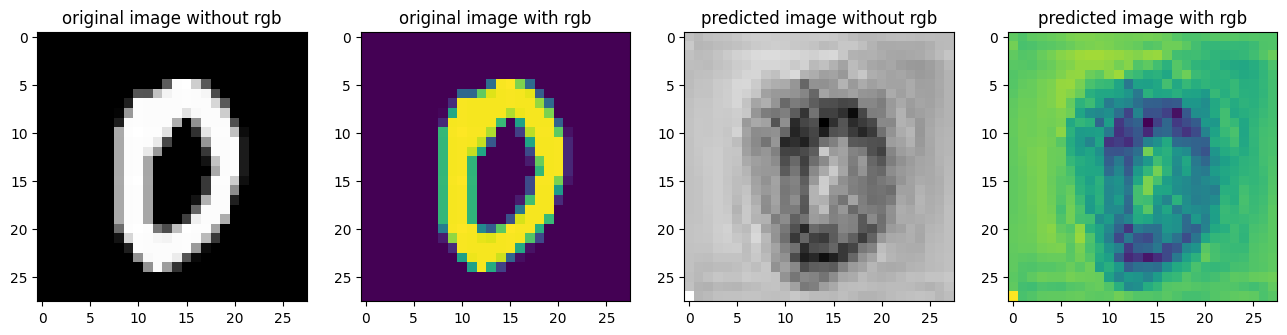

100%|██████████| 375/375 [00:13<00:00, 26.85it/s]


epoch 1 loss 0.0031572974768156806


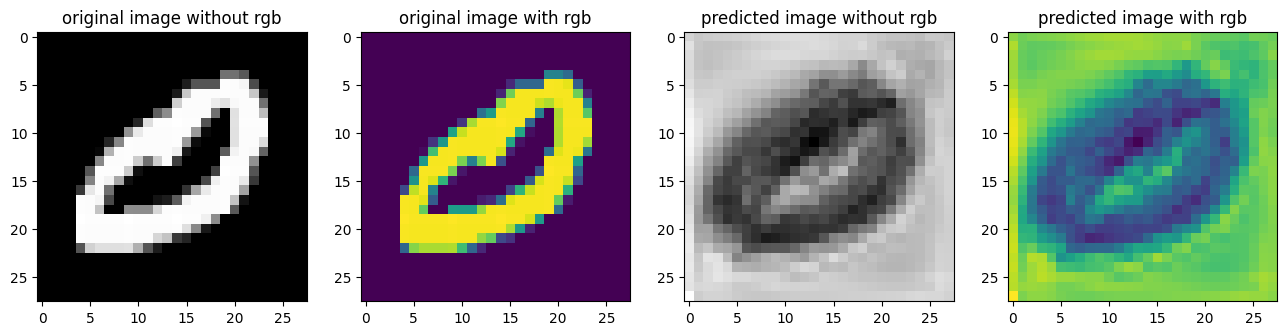

100%|██████████| 375/375 [00:13<00:00, 27.47it/s]


epoch 2 loss 0.00163345891268303


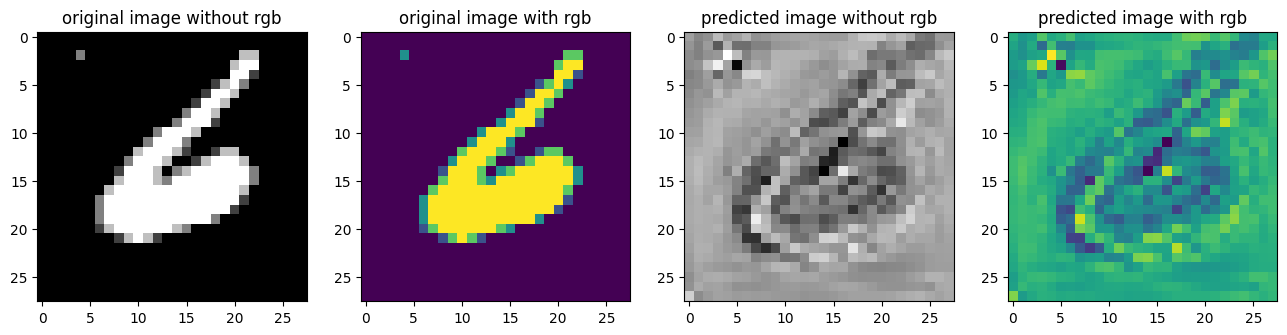

100%|██████████| 375/375 [00:14<00:00, 25.69it/s]


epoch 3 loss 0.0010683578775885205


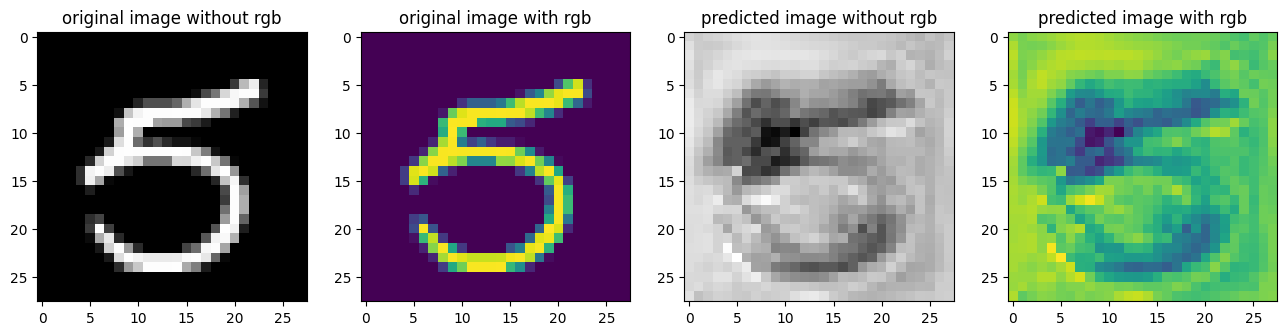

100%|██████████| 375/375 [00:13<00:00, 27.58it/s]


epoch 4 loss 0.0008425830881266545


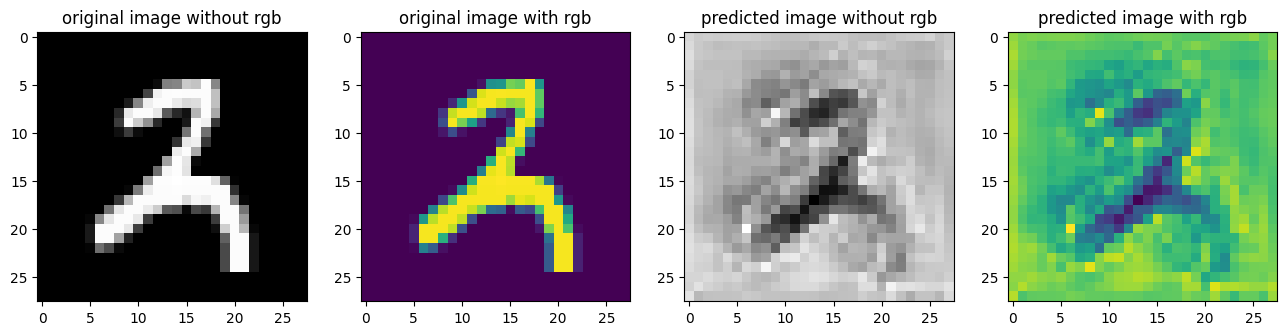

100%|██████████| 375/375 [00:13<00:00, 27.46it/s]


epoch 5 loss 0.0006419707734603435


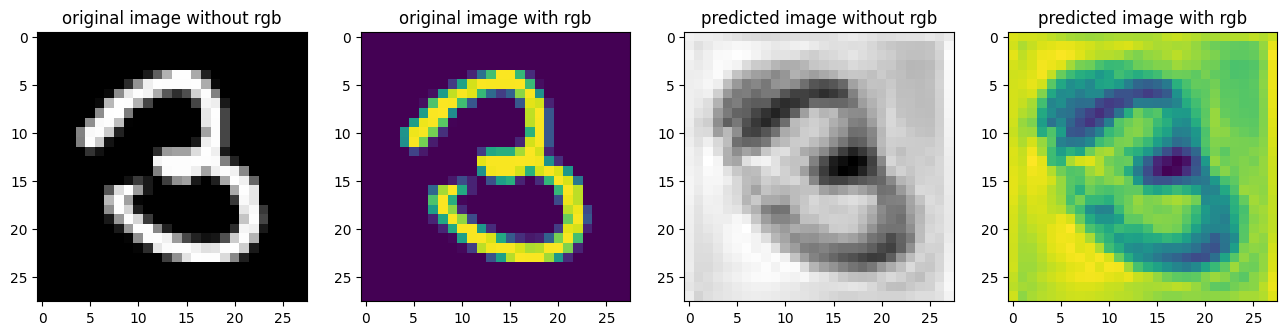

100%|██████████| 375/375 [00:13<00:00, 27.40it/s]


epoch 6 loss 0.000683369324154531


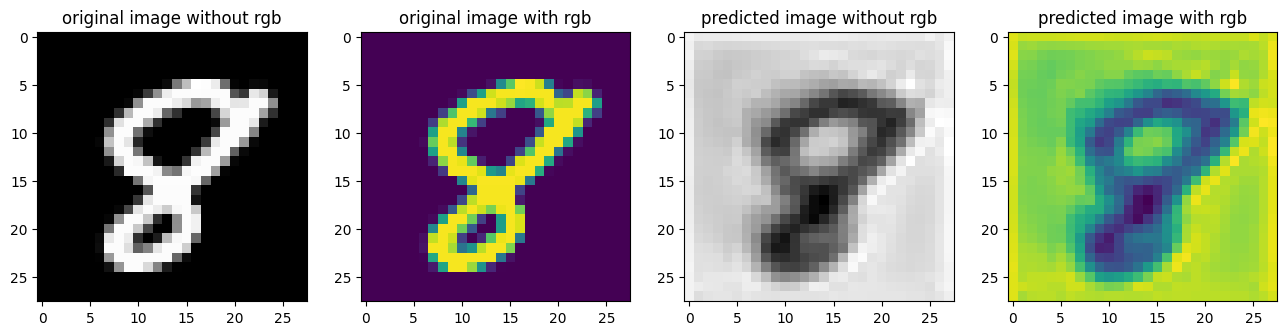

100%|██████████| 375/375 [00:13<00:00, 27.38it/s]


epoch 7 loss 0.00048487945133820175


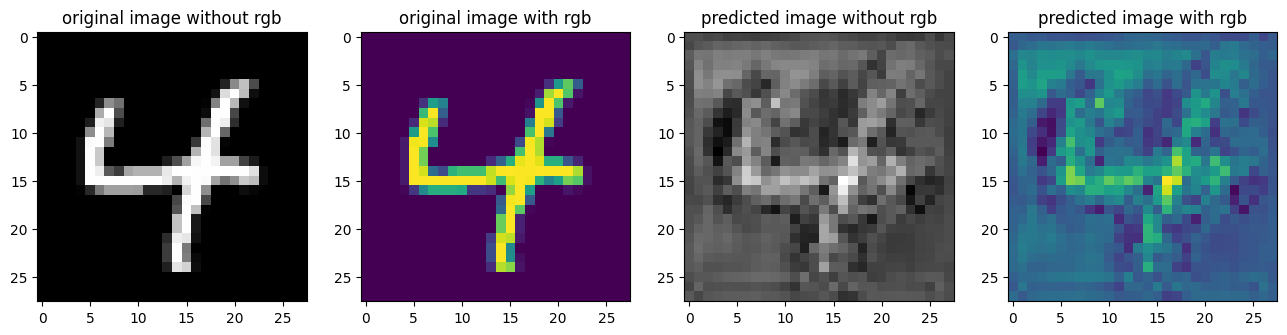

100%|██████████| 375/375 [00:13<00:00, 27.42it/s]


epoch 8 loss 0.0004619996688561514


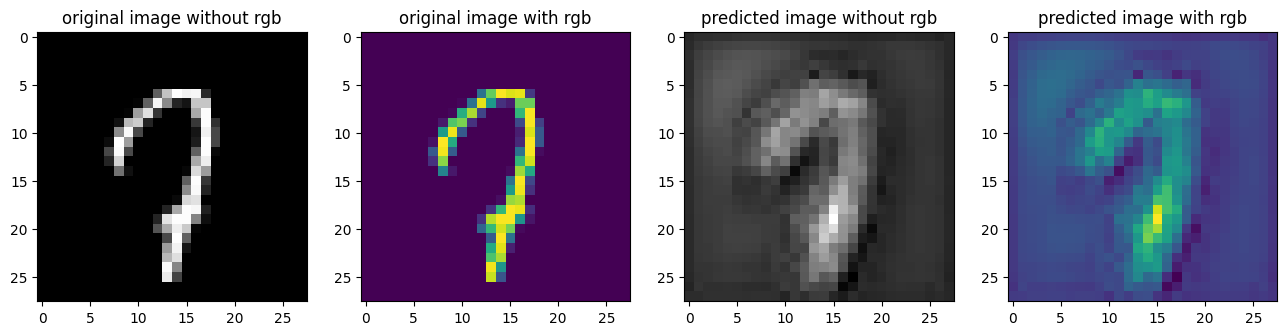

100%|██████████| 375/375 [00:13<00:00, 27.47it/s]


epoch 9 loss 0.00044543242561242855


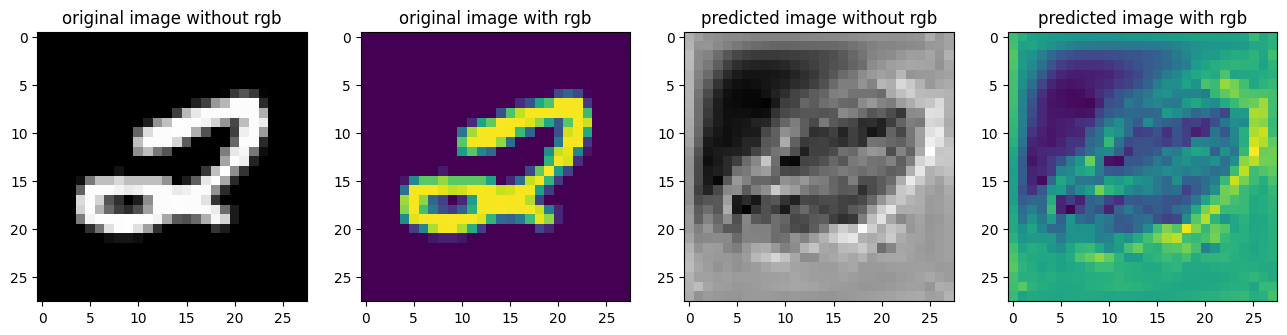

100%|██████████| 375/375 [00:13<00:00, 27.37it/s]


epoch 10 loss 0.00036722959564455473


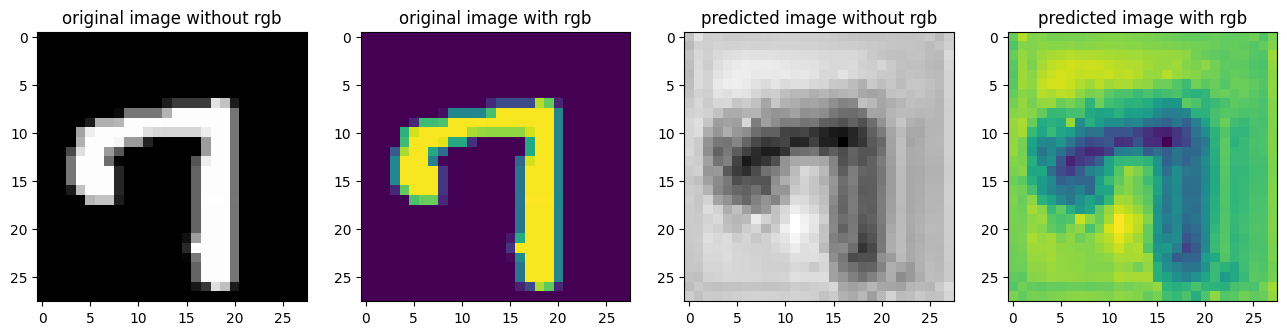

100%|██████████| 375/375 [00:13<00:00, 27.43it/s]


epoch 11 loss 0.00027539939885415756


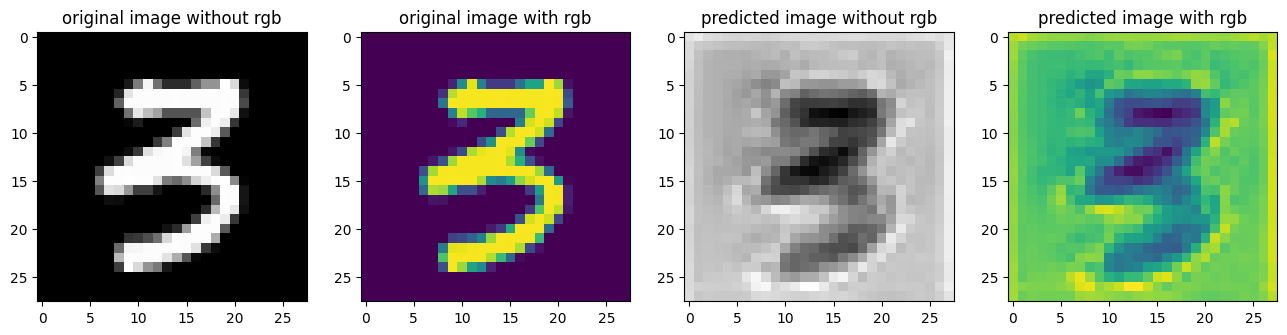

100%|██████████| 375/375 [00:13<00:00, 27.39it/s]


epoch 12 loss 0.0002714643504684015


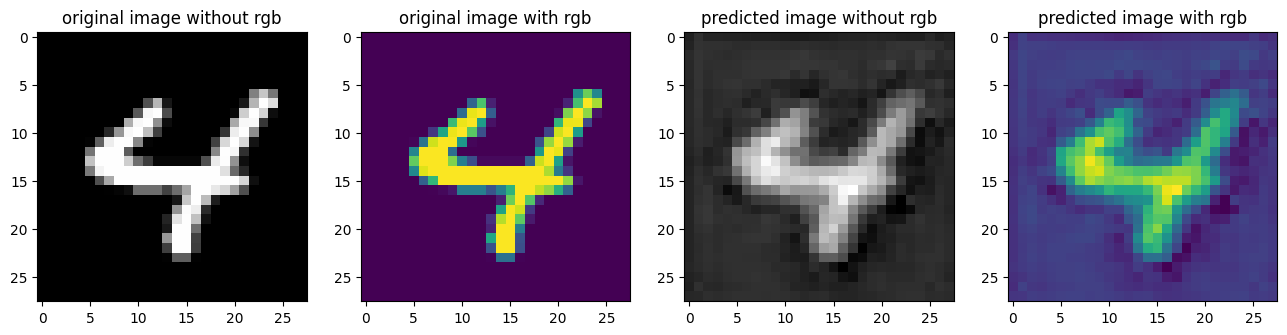

100%|██████████| 375/375 [00:13<00:00, 27.40it/s]


epoch 13 loss 0.00020771286884943644


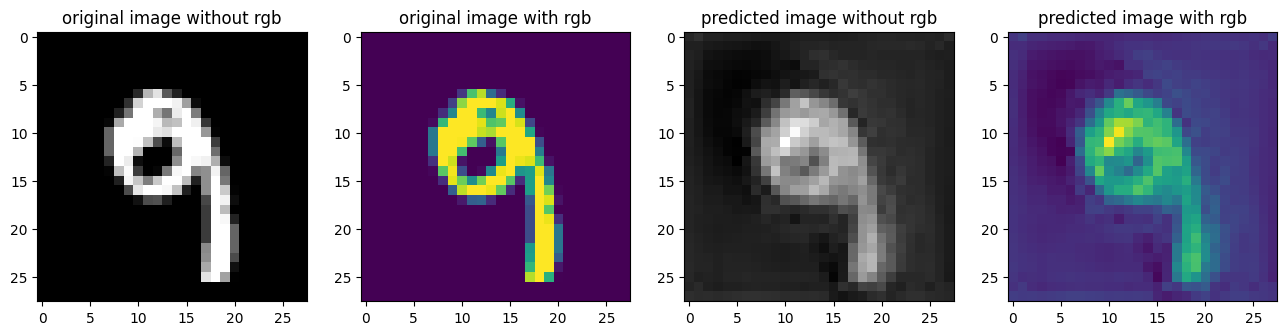

100%|██████████| 375/375 [00:13<00:00, 27.41it/s]


epoch 14 loss 0.00023399635555688291


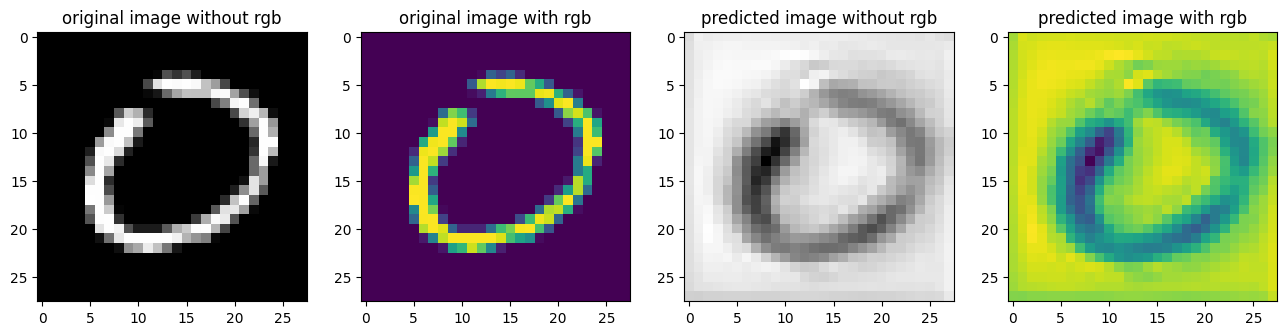

100%|██████████| 375/375 [00:13<00:00, 27.37it/s]


epoch 15 loss 0.00022946258252098535


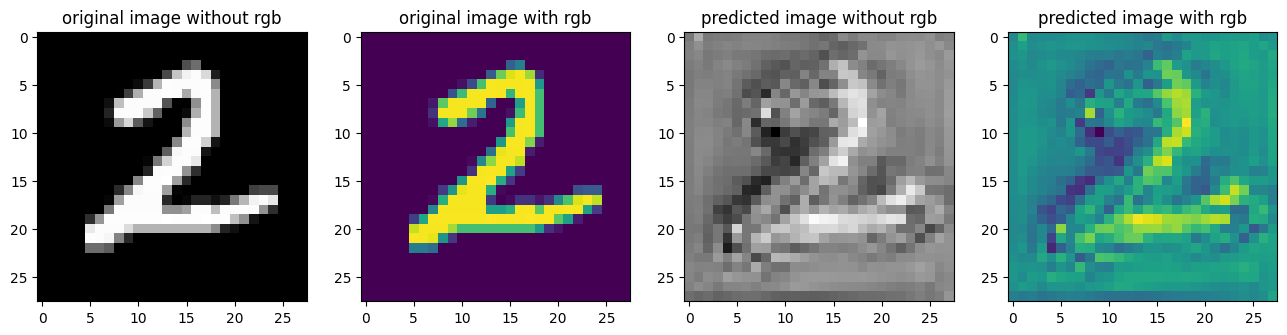

100%|██████████| 375/375 [00:13<00:00, 27.38it/s]


epoch 16 loss 0.00017378916147572454


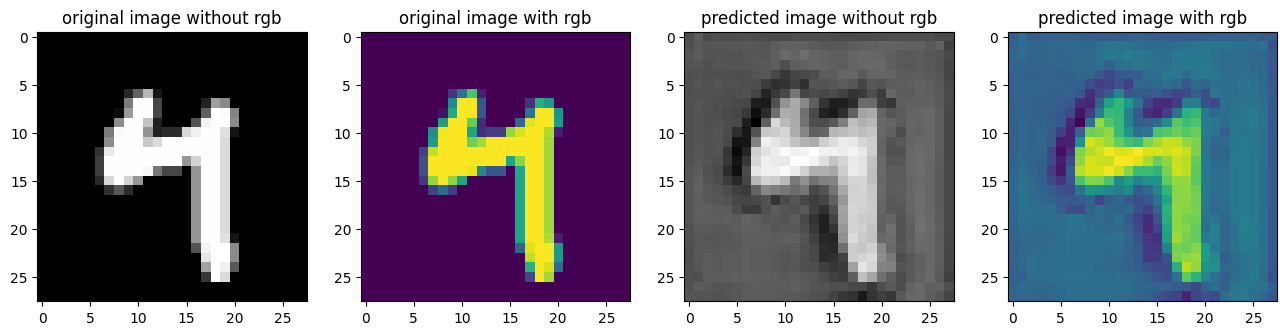

100%|██████████| 375/375 [00:13<00:00, 27.36it/s]


epoch 17 loss 0.00019725308394117746


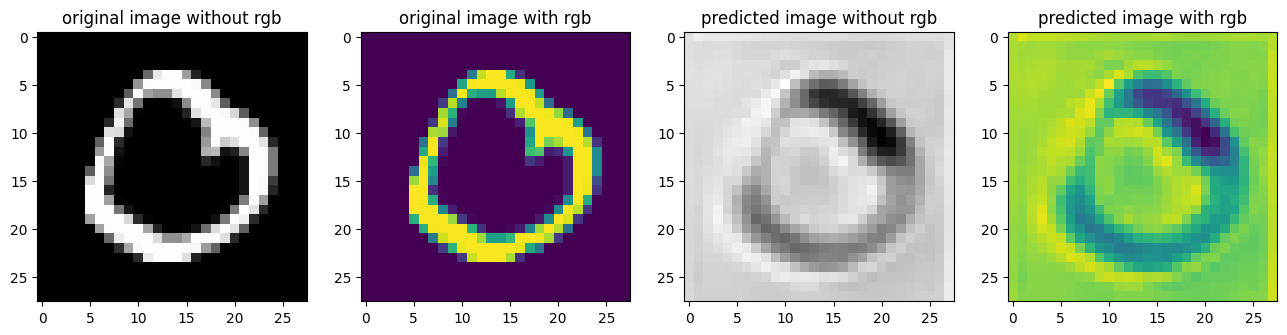

100%|██████████| 375/375 [00:13<00:00, 27.40it/s]


epoch 18 loss 0.00024199419338644172


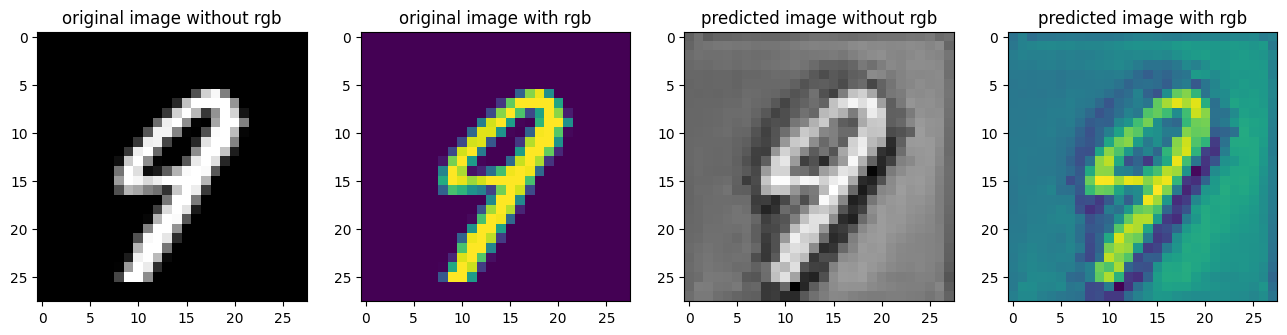

100%|██████████| 375/375 [00:13<00:00, 27.39it/s]


epoch 19 loss 0.00013099677680778162


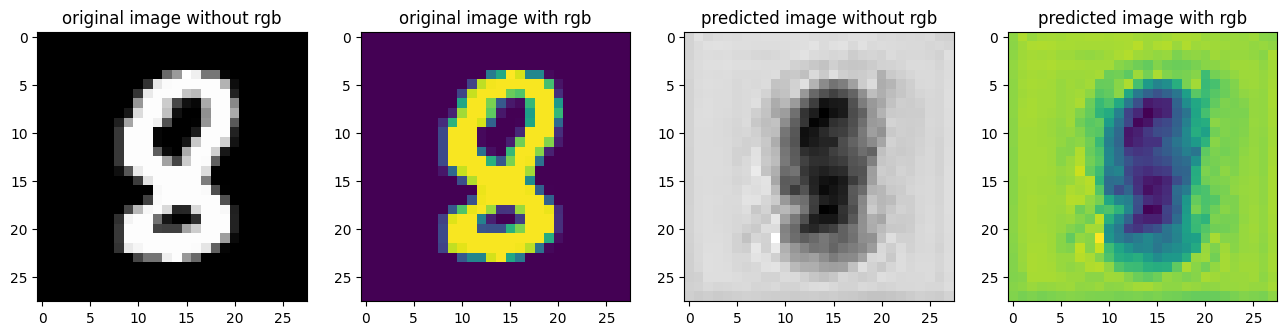

In [458]:
batch_size = 128
# original with 186  images and 186 * 20 expand
# each epoch will do train_length/batch_size times train, every time take 50 images batch to train, every epoch takes 74 * 50 images, total 74 * 50 * 10 images to train, repeat or no repeat images, random
for epoch in range(20):
    fig, ax = plt.subplots(1, 4, figsize=(16, 8))

    #eg. all 186 images, every epoch choose 3720 // 50 times to train
    # every time choose 50 images, and the target is the same image, because it is an autoencoder
    train__num = train_length // batch_size

    train_loss = 0

    for i in tqdm(range(train__num)):
        # choose random batch_size images from x_train, and the target is the same image, because it is an autoencoder
        indices = np.random.randint(0, x_train.shape[0], size=batch_size)
        x_imgs_batch = x_train[indices]  # get numpy array
        # autoencoder is to rebuild the input image, so the target is the same image
        y_batch = x_imgs_batch  # the target is the same image, because it is an autoencoder

        # ✅ convert numpy array to tensor（share memory）
        # neural network need float tensor  float32 is the most common and efficient data type for training, and it is the default data type for PyTorch tensors
        x_imgs_batch = torch.from_numpy(x_imgs_batch).float().to(device)
        y_batch = torch.from_numpy(y_batch).float().to(device)

        # forward pass
        pred = model(x_imgs_batch)
        # compare the pixel value of the predicted image and the target image, and calculate the loss, the smaller the loss, the better the model
        criterion = torch.nn.MSELoss(reduction='mean')
        loss = criterion(pred, y_batch) * 100

        # backward pass and update the model parameters
        # every turn gradient to zero
        optimizer.zero_grad()
        # gradient
        loss.backward()
        # update parameters (w,b)
        optimizer.step()

        train_loss += loss.item()

    # average loss for this epoch
    train_loss = train_loss / train__num
    print(f"epoch {epoch} loss {train_loss}")

    # save the last model
    # model.sate_dict() only save the parameters of the model, not the whole model, so it is more efficient and flexible, but need to define the model structure when loading the model, and it is the recommended way to save and load models in PyTorch
    if epoch % 19 == 0 and epoch != 0:
        torch.save(model.state_dict(), f"1my_unet_model_{epoch}.pt")
        # save the whole model (structure + parameters)
        # torch.save(model, f"my_unet_model_{epoch}.pt")

    # use the saved model
    """
        for loading the whole model
    model = torch.load(f"my_unet_model_{epoch}.pt")
    model.eval()
    with torch.no_grad(): # dont save the this time gradient parameters, for testing and inference
        pred = model(image)

    for loading the model parameters
    model = unet.Unet()  # define the model structure, must be the same as the one used for training, otherwise it will not work
    model.load_state_dict(torch.load(f"my_unet_model_{epoch}.pt"))
    model.eval()
    """

    # graph
    idx = np.random.randint(0, x_train.shape[0])
    image = x_train[idx:idx+1]  # shape: (1, 1, 28, 28)
    original = x_train[idx].reshape(28,28)
    image = torch.from_numpy(image).float().to(device)
    pred = model(image)

    image = pred.detach().cpu().numpy().reshape(28, 28)
    ax[0].imshow(original, cmap='gray')
    ax[0].set_title("original image without rgb")
    ax[1].imshow(original)
    ax[1].set_title("original image with rgb")
    ax[2].imshow(image, cmap='gray')
    ax[2].set_title("predicted image without rgb")
    ax[3].imshow(image)
    ax[3].set_title("predicted image with rgb")
    plt.show()

In [459]:
def pixel_accuracy(pred, target, threshold=0.5):
    """
    预测值与目标值的像素匹配比例
    """
    # Convert inputs to PyTorch tensors if they are NumPy arrays
    if isinstance(pred, np.ndarray):
        pred_tensor = torch.from_numpy(pred).float()
    else:
        pred_tensor = pred

    if isinstance(target, np.ndarray):
        target_tensor = torch.from_numpy(target).float()
    else:
        target_tensor = target

    pred_binary = (pred_tensor > threshold).float()
    target_binary = (target_tensor > threshold).float()
    correct = (pred_binary == target_binary).float().sum()
    total = target_binary.numel()  # Now target_binary is guaranteed to be a torch.Tensor
    return (correct / total).item()


def calculate_psnr(pred, target, max_val=1.0):
    """
    PSNR 越高越好
    > 30 dB: 质量较好
    > 40 dB: 质量很好
    """
    mse = torch.mean((pred - target) ** 2)
    if mse == 0:
        return float('inf')
    psnr = 20 * torch.log10(max_val / torch.sqrt(mse))
    return psnr.item()


In [460]:
def test_model(image):
  image_test = image.reshape(1, 1, 28,28)
  image_test = torch.from_numpy(image_test).float().to(device)
  with torch.no_grad():
    pred = model(image_test)
    criterion = torch.nn.MSELoss(reduction="mean")
    loss = criterion(pred, image_test) * 100
    p = pred
    accurary = pixel_accuracy(p, image_test)
    psnr = calculate_psnr(p, image_test)
    pred = pred.detach().cpu().numpy().reshape(28, 28)
    image = image.reshape(28, 28)
    accurary = pixel_accuracy(pred, image)
    print("accuracy is ", accurary)
    print("psnr is ", psnr)

    fig, axes = plt.subplots(1, 4, figsize=(16, 8))
    axes = axes.flatten()
    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("original image")
    axes[1].imshow(image)
    axes[1].set_title("original image with color")
    axes[2].imshow(pred, cmap="gray")
    axes[2].set_title("predicted image")
    axes[3].imshow(pred)
    axes[3].set_title("predicted image with color")
    plt.show()
    print("loss is ", loss)

9
accuracy is  0.6823979616165161
psnr is  -9.667226791381836


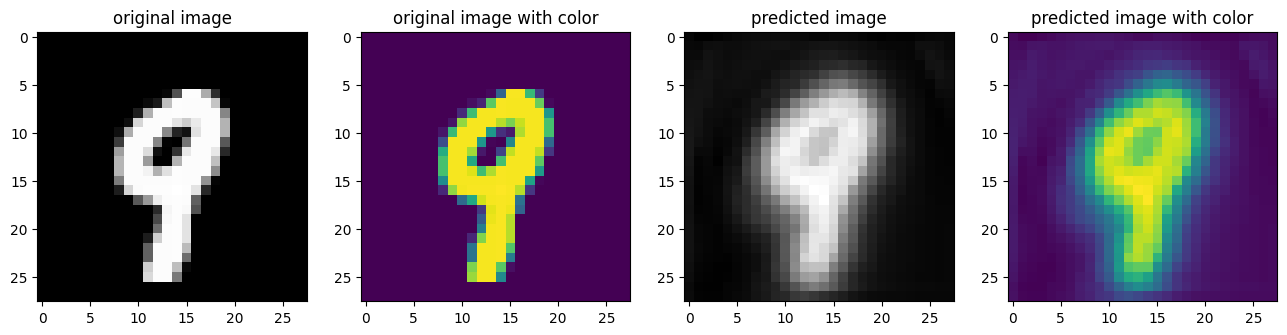

loss is  tensor(926.2380)


In [461]:
device = "cpu"
model = UnetUpsamle()
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.load_state_dict(torch.load("/content/1my_unet_model_19.pt"))
model.eval()
image = y_train[3]
print(y_test[3])
test_model(image)


9
accuracy is  1.0
psnr is  58.1702995300293


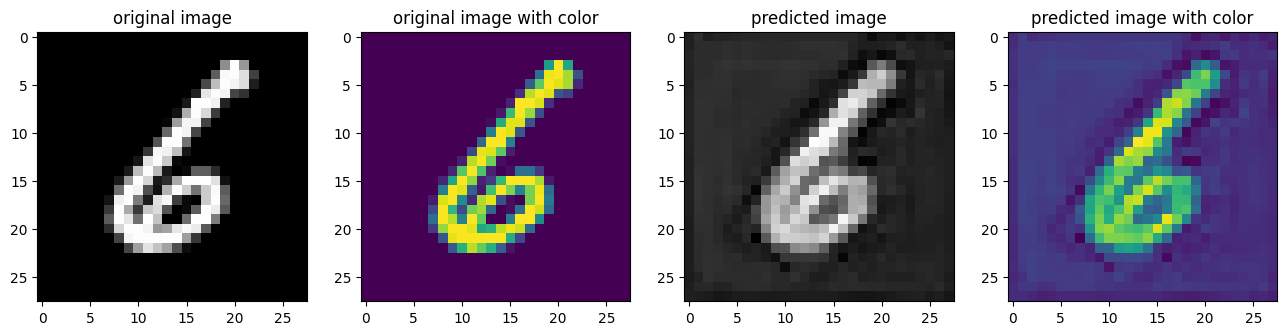

loss is  tensor(0.0002)


In [462]:
image = x_train[3]
print(y_test[3])
test_model(image)